# Отток клиентов

# Customer Churn Prediction


Из «Бета-Банка» стали уходить клиенты. Каждый месяц. Немного, но заметно. Банковские маркетологи посчитали: сохранять текущих клиентов дешевле, чем привлекать новых.

Нужно спрогнозировать, уйдёт клиент из банка в ближайшее время или нет. Вам предоставлены исторические данные о поведении клиентов и расторжении договоров с банком.

Постройте модель с предельно большим значением *F1*-меры. Чтобы сдать проект успешно, нужно довести метрику до 0.59. Проверьте *F1*-меру на тестовой выборке самостоятельно.

Дополнительно измеряйте *AUC-ROC*, сравнивайте её значение с *F1*-мерой.

Источник данных: [https://www.kaggle.com/barelydedicated/bank-customer-churn-modeling](https://www.kaggle.com/barelydedicated/bank-customer-churn-modeling)

---

Customers have started leaving **Beta Bank**. Every month. Not massively, but noticeably. The bank’s marketing team has concluded that retaining existing customers is cheaper than acquiring new ones.

The task is to predict whether a client will leave the bank in the near future. You are provided with historical data on customer behavior and contract terminations.

Build a model with the highest possible **F1 score**. To successfully complete the project, the metric must reach at least **0.59**. Evaluate the **F1 score** on the test set independently.

Additionally, measure **AUC-ROC** and compare its value with the **F1 score**.

Data source: [https://www.kaggle.com/barelydedicated/bank-customer-churn-modeling](https://www.kaggle.com/barelydedicated/bank-customer-churn-modeling)

#### Цель проекта:
Построить модель для задачи классификации, способную проанализировать, уйдёт ли клиент из банка в ближайшее время, на основе данных о его поведении.

##### Ход исследования:
1. Подготовка данных:
   - Загрузка данных, чтение файла, сохранение его в датасет, изучение общей информации.
   - Обработка пропусков.
   - Преобразование текстовых значений в числовые.
   - Разделение данных на выборки по признакам.
2. Исследование баланса классов:
   - Оценка модели логистической регрессии на данных без балансировки классов.
3. Борьба с дисбалансом:
   - Приведение классов к балансу.
   - Оценка эффективности разных моделей.
4. Финальное тестирование модели:
   - Оценка результатов модели.
   - Визуализация и оценка ROC-AUC кривой модели.
5. Общий вывод.

---

#### Project Objective:
To build a classification model capable of predicting whether a bank customer will leave in the near future based on data about their behavior.

##### Research Plan:
1. Data preparation:
   - Loading the data, reading the file, storing it in a dataset, and examining the general information.
   - Handling missing values.
   - Converting textual values into numerical ones.
   - Splitting the data into feature-based subsets.
2. Class balance analysis:
   - Evaluating a logistic regression model on data without class balancing.
3. Handling class imbalance:
   - Balancing the classes.
   - Evaluating the performance of different models.
4. Final model testing:
   - Assessing model performance.
   - Visualizing and evaluating the ROC-AUC curve.
5. Overall conclusion.

## Этап 1. Подготовка данных.

### Импортируем библиотеки и модули:

In [1]:
#Импортируем библиотеку Pandas
import pandas as pd
#Импортируем модуль train_test_split из библиотеке scikit-learn для разделения на выборки
from sklearn.model_selection import train_test_split
#Импортируем модуль для оценки гиперпараметров моделей
from sklearn.model_selection import GridSearchCV
#Импортируем модуль логистической регрессии
from sklearn.linear_model import LogisticRegression
#Импортируем фукнцию classification_report, предназначенную для оценки качества предсказаний модели классификации
from sklearn.metrics import classification_report
#Импортируем модель дерева
from sklearn.tree import DecisionTreeClassifier
#Импортируем модель случайного леса 
from sklearn.ensemble import RandomForestClassifier
#Импортируем метрику auc_roc
from sklearn.metrics import roc_auc_score, roc_curve
#Импортируем библиотеку для визуализации
import matplotlib.pyplot as plt
#Для подавления предупреждений
from sklearn.exceptions import ConvergenceWarning
import warnings
#Для метрик оценки
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report
#Масштабирование количественных признаков
from sklearn.preprocessing import StandardScaler
#Pipeline, SMOTE, RandomUnderSampler
!pip install --upgrade scikit-learn imbalanced-learn
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import OneHotEncoder

### Загрузка данных:

In [2]:
#Прочитаем файл и сохраним его в переменную
try:
    data = pd.read_csv('/Users/danielschollenberg/Desktop/Churn.csv')
except:
    data = pd.read_csv('https://code.s3.yandex.net/datasets/Churn.csv')

In [3]:
display(data.head())
print(data.info())

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB
None


#### Вывод:
- Датасет состоит из 10000 объектов(строк) и 14 признаков(столбцов) следующего содержания:
   - RowNumber — индекс строки в данных
   - CustomerId — уникальный идентификатор клиента
   - Surname — фамилия
   - CreditScore — кредитный рейтинг
   - Geography — страна проживания
   - Gender — пол
   - Age — возраст
   - Tenure — сколько лет человек является клиентом банка
   - Balance — баланс на счёте
   - NumOfProducts — количество продуктов банка, используемых клиентом
   - HasCrCard — наличие кредитной карты
   - IsActiveMember — активность клиента
   - EstimatedSalary — предполагаемая зарплата
   - Exited — факт ухода клиента
- Целевым признаком является столбец:
   - Exited — факт ухода клиента
- Задача является задачей бинарной классификации.

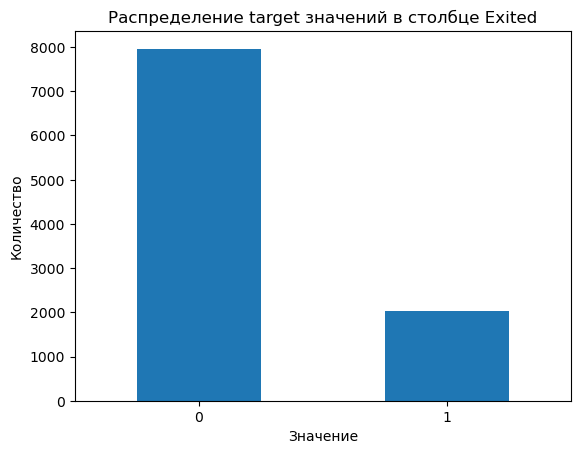

Процент количества строк со значением 0 в столбце:
79.63 %
Процент количества строк со значением 1 в столбце:
20.37 %


In [4]:
#Изучим дисбаланс значений в столбце Exited
data['Exited'].value_counts().plot(kind='bar')
plt.xlabel('Значение')
plt.ylabel('Количество')
plt.xticks(rotation=0) 
plt.title('Распределение target значений в столбце Exited')
plt.show()
print('Процент количества строк со значением 0 в столбце:')
print(data['Exited'].value_counts()[0] / (len(data['Exited'])/100), '%')
print('Процент количества строк со значением 1 в столбце:')
print(data['Exited'].value_counts()[1] / (len(data['Exited'])/100), '%')

#### Вывод:
- В target столбце 'Exited' обозначающим факт ухода клиента из банка есть явный дисбаланс и перевес в сторону значения '0', - почти 80% всех значений. Это обозначает, что большинство людей из базы данных, на момент ее получения, все еще являются клиентами банка.

### Обработка пропусков:

In [5]:
data.isnull().sum()

RowNumber            0
CustomerId           0
Surname              0
CreditScore          0
Geography            0
Gender               0
Age                  0
Tenure             909
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Exited               0
dtype: int64

#### Вывод:
- Пропущенные значения в столбце Tenure - сколько лет человек является клиентом банка, скорее всего обозначают 0, заменим их на ноль.

In [6]:
#Заполнение пропущенных значений в столбце 'Tenure' значением 0
data['Tenure'] = data['Tenure'].fillna(0)

### Очистка признаков:

- Для дальнейших действий нам нужно преобразовать строковые значения в числовые, однако перед этим есть необходимость в избавления от неинформативных столбцов: 'RowNumber', 'CustomerId', 'Surname'. Данные столбцы содержат информацию, которая никак не влияет на вероятность потенциального ухода клиента, но забирают вычислительные ресурсы и время в процессе обработки моделью данных.

In [7]:
#Удаляем столбец
data = data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

#Используя pandas get_dummies преобразуем строковые значений в числовые техникой One-Hot Encoding и
#сохраним результат в новый датафрейм data_ohe
data_ohe = pd.get_dummies(data, drop_first=True)

#### Вывод:
   - Мы удалили бесполезный столбец и преобразовали строковые значения в числовые - теперь данные готовы к следующим этапам.

### Разделение данных по признакам:

In [8]:
#Разделение данных по признакам
features = data.drop(['Exited'], axis=1)
target = data['Exited']

#Разделяем данные на обучающий и тестовый наборы
features_train, features_test, target_train, target_test = train_test_split(
                                                                            features,
                                                                            target,
                                                                            test_size=0.6,
                                                                            random_state=12345,
                                                                            stratify=target
                                                                            )

In [9]:
#список категориальных столбцов
categorical_columns = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember'] 

#Преобразование категориальных столбцов в строки
for col in categorical_columns:
    features_train[col] = features_train[col].astype(str)
    features_test[col] = features_test[col].astype(str)
    
#Создание и обучение OneHotEncoder
encoder_ohe = OneHotEncoder(drop='first', handle_unknown='ignore')
encoder_ohe.fit(features_train[categorical_columns])

#Преобразование тренировочных данных
encoded_train = pd.DataFrame(encoder_ohe.transform(features_train[categorical_columns]).toarray(),
                             columns=encoder_ohe.get_feature_names_out(categorical_columns),
                             index=features_train.index)
features_train = pd.concat([features_train.drop(columns=categorical_columns), encoded_train], axis=1)

#Преобразование тестовых данных
encoded_test = pd.DataFrame(encoder_ohe.transform(features_test[categorical_columns]).toarray(),
                            columns=encoder_ohe.get_feature_names_out(categorical_columns),
                            index=features_test.index)
features_test = pd.concat([features_test.drop(columns=categorical_columns), encoded_test], axis=1)

In [10]:
#Запишем количественные переменные
quant_columns = ['CreditScore', 'Age', 'Tenure', 'NumOfProducts', 'Balance', 'EstimatedSalary']

#Создадим scaler
scaler = StandardScaler()

#Обучим на тренировочной выборке
scaler.fit(features_train[quant_columns])

#Масштабируем тренировочную выборку
scaled_features_train = scaler.transform(features_train[quant_columns])

#Масштабируем тестовую выборку
scaled_features_test = scaler.transform(features_test[quant_columns])

In [11]:
#Объединяем dataset с обработаными категориальными признаками 
#и датасетом с количественными признаками после шкалирования
features_train.loc[:, quant_columns] = scaled_features_train
features_test.loc[:, quant_columns] = scaled_features_test

In [12]:
features_train.head(3)

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male,HasCrCard_1,IsActiveMember_1
3547,0.114627,-0.372209,0.470650,-1.211706,0.808678,-1.689972,0.0,1.0,0.0,0.0,0.0
4559,-1.267543,2.255662,0.791859,0.913776,-0.939815,1.194581,1.0,0.0,0.0,0.0,0.0
4761,1.527741,-0.664194,-0.492974,0.480462,0.808678,-1.420522,0.0,0.0,0.0,1.0,1.0


In [13]:
#Преобразование типов столбцов в числа
for col in features_test:
    features_train[col] = features_train[col].astype(float)
    features_test[col] = features_test[col].astype(float)

#### Вывод:
- Мы разбили данные по признакам.
- Провели масштабирование количественных признаков
- Разбили выборки на обучающую и тестовую

## Этап 2. Исследование баланса классов.

In [14]:
#Создадим экземпляр модели логистической регрессии
model = LogisticRegression()

In [15]:
#Подавление всех предупреждений
warnings.filterwarnings("ignore")

In [16]:
#Определение сетки гиперпараметров
param_grid = {
    'max_iter': [100, 200, 400, 800],
    'solver': ["liblinear", "newton-cg", "lbfgs", "sag", "saga"]
}

#Создание экземпляра GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=4)

grid_search.fit(features_train, target_train)

#Получение лучшей модели
best_model = grid_search.best_estimator_

# Получение лучших параметров
best_params = grid_search.best_params_

#Получение предсказаний модели на всех фолдах кросс-валидации
y_pred = cross_val_predict(best_model, features_train, target_train, cv=4)

#Вывод classification_report с precision, recall и F1-score для каждого класса
print(classification_report(target_train, y_pred))
print('Лучшие параметры:', best_params)

              precision    recall  f1-score   support

           0       0.83      0.96      0.89      3185
           1       0.62      0.23      0.33       815

    accuracy                           0.81      4000
   macro avg       0.72      0.60      0.61      4000
weighted avg       0.79      0.81      0.78      4000

Лучшие параметры: {'max_iter': 100, 'solver': 'liblinear'}


#### Описание метрик классификации
##### Общая производительность модели:

- Accuracy (точность): Модель корректно классифицирует 84% всех случаев. Это указывает на достаточно высокую общую точность модели.

- Для класса 0 (например, отрицательный класс):

  - Precision: 0.86 означает, что из всех случаев, классифицированных как класс 0, 86% действительно принадлежат классу 0. Это указывает на высокую точность предсказаний модели для этого класса.
  - Recall: 0.95 показывает, что модель успешно идентифицировала 95% всех реальных случаев класса 0. Это свидетельствует о том, что модель очень эффективно распознает класс 0.
  - F1-score: 0.90 является средним гармоническим между precision и recall, что демонстрирует хороший баланс между точностью и полнотой для класса 0.
- Для класса 1 (например, положительный класс):

  - Precision: 0.68 означает, что из всех случаев, классифицированных как класс 1, 68% действительно принадлежат классу 1. Это меньше по сравнению с классом 0, что может указывать на проблемы с классификацией положительных случаев.
  - Recall: 0.41 говорит о том, что модель выявляет только 41% всех реальных случаев класса 1. Это относительно низкое значение указывает на слабую способность модели обнаруживать положительные случаи.
  - F1-score: 0.51 указывает на умеренный баланс между precision и recall для класса 1, что ниже по сравнению с классом 0.
- Лучшие параметры модели
  - max_iter (максимальное количество итераций): 100. 
   - solver (решатель(алгоритм решения)): 'liblinear'. 


- Выводы:
   - Модель показывает хорошую способность предсказывать отрицательные случаи (класс 0), что подтверждается высокими значениями precision и recall.
  - Для положительного класса (класс 1) результаты менее удовлетворительные, особенно в плане recall, что может указывать на проблемы с обнаружением положительных случаев в условиях, возможно, существующего дисбаланса классов.
  - Эффективность модели в классификации класса 1 может быть улучшена за счет техник балансировки классов, более глубокой настройки гиперпараметров или использования более сложных моделей.

## Этап 3. Борьба с дисбалансом. Приведение классов к балансу.

### Обучим модель логистической регрессии с приведением классов к балансу, оценим результат:

In [17]:
#Создадим модель
model_lr_balanced = LogisticRegression(class_weight='balanced', random_state=12345)

#Создание экземпляра GridSearchCV
grid_search_balanced = GridSearchCV(estimator=model_lr_balanced, param_grid=param_grid, cv=4)

#Подгонка модели
grid_search_balanced.fit(features_train, target_train)

#Получение лучшей модели
best_model = grid_search_balanced.best_estimator_

# Получение лучших параметров
best_params = grid_search_balanced.best_params_

#Получение предсказаний модели на всех фолдах кросс-валидации
y_pred = cross_val_predict(best_model, features_train, target_train, cv=4)

#Вывод classification_report с precision, recall и F1-score для каждого класса
print(classification_report(target_train, y_pred))
print('Лучшие параметры:', best_params)

              precision    recall  f1-score   support

           0       0.90      0.73      0.81      3185
           1       0.40      0.69      0.51       815

    accuracy                           0.73      4000
   macro avg       0.65      0.71      0.66      4000
weighted avg       0.80      0.73      0.75      4000

Лучшие параметры: {'max_iter': 100, 'solver': 'liblinear'}


#### Описание метрик классификации для новых результатов
##### Общая производительность модели:

- Accuracy (точность): Модель корректно классифицирует 77% всех случаев. Это ниже, чем в предыдущем случае, указывая на снижение общей точности.

- Для класса 0 (например, отрицательный класс):

  - Precision: 0.91 означает, что из всех случаев, классифицированных как класс 0, 91% действительно принадлежат классу 0. Это показатель высокой точности предсказаний модели для этого класса.
  - Recall: 0.80 показывает, что модель успешно идентифицировала 80% всех реальных случаев класса 0. Это хороший показатель, но ниже, чем в предыдущем анализе, что может свидетельствовать о том, что модель стала чаще ошибаться, пропуская некоторые случаи класса 0.
  - F1-score: 0.85 представляет собой меру баланса между precision и recall, указывая на хорошее соотношение, но с небольшим снижением по сравнению с предыдущим анализом.
- Для класса 1 (например, положительный класс):

  - Precision: 0.46 означает, что из всех случаев, классифицированных как класс 1, 46% действительно принадлежат классу 1. Это значительно ниже, чем для класса 0, что указывает на проблемы с точностью предсказания положительных случаев.
  - Recall: 0.69 говорит о том, что модель выявляет 69% всех реальных случаев класса 1. Это улучшение по сравнению с предыдущими результатами, что свидетельствует о том, что модель стала лучше распознавать положительные случаи, несмотря на увеличение числа ложных срабатываний.
  - F1-score: 0.55 указывает на умеренное улучшение баланса между precision и recall для класса 1 по сравнению с предыдущим анализом.
  
  
- Лучшие параметры модели остались такие-же
  - max_iter (максимальное количество итераций): 100
  - solver (решатель): 'liblinear'
  
- Выводы:
  - Для класса 0: Модель по-прежнему показывает высокую точность, но её способность к идентификации всех реальных случаев класса 0 снизилась.
  - Для класса 1: Модель улучшила свою способность к идентификации положительных случаев, хотя это привело к увеличению числа ложноположительных срабатываний, что снизило общую точность предсказаний для этого класса.
  - Таким образом, модель показывает смещение в сторону улучшения recall за счет снижения precision, особенно для класса 1.

### Обучим модель решающего дерева с приведением классов к балансу, оценим результат:

In [18]:
#Создадим модель
model_dtc_balanced = DecisionTreeClassifier(class_weight='balanced', random_state=12345)

# Определение сетки параметров для поиска
param_grid = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [5, 25, 125]
}

#Создание экземпляра GridSearchCV
grid_search_balanced = GridSearchCV(estimator=model_dtc_balanced, param_grid=param_grid, cv=4)

#Подгонка модели
grid_search_balanced.fit(features_train, target_train)

#Получение лучшей модели
best_model = grid_search_balanced.best_estimator_

# Получение лучших параметров
best_params = grid_search_balanced.best_params_

#Получение предсказаний модели на всех фолдах кросс-валидации
y_pred = cross_val_predict(best_model, features_train, target_train, cv=4)

#Вывод classification_report с precision, recall и F1-score для каждого класса
print(classification_report(target_train, y_pred))
print('Лучшие параметры:', best_params)

              precision    recall  f1-score   support

           0       0.87      0.87      0.87      3185
           1       0.49      0.48      0.49       815

    accuracy                           0.79      4000
   macro avg       0.68      0.68      0.68      4000
weighted avg       0.79      0.79      0.79      4000

Лучшие параметры: {'criterion': 'entropy', 'max_depth': 25, 'splitter': 'random'}


#### Описание метрик классификации для новых результатов
##### Общая производительность модели:

- Accuracy (точность): Модель корректно классифицирует 79% всех случаев, что показывает умеренную общую эффективность.

- Для класса 0 (например, отрицательный класс):

   - Precision: 0.87 означает, что из всех случаев, классифицированных как класс 0, 87% действительно принадлежат классу 0. Это отражает высокую точность предсказаний модели для этого класса.
  - Recall: 0.86 показывает, что модель успешно идентифицировала 86% всех реальных случаев класса 0. Это довольно высокий показатель, указывающий на хорошую способность модели распознавать отрицательные случаи.
   - F1-score: 0.86 представляет собой среднее гармоническое между precision и recall, указывая на сбалансированное соотношение точности и полноты.
   
- Для класса 1 (например, положительный класс):

  - Precision: 0.48 означает, что из всех случаев, классифицированных как класс 1, 48% действительно принадлежат классу 1. Это указывает на проблемы с точностью предсказания положительных случаев, поскольку почти половина предсказаний оказывается неверной.
  - Recall: 0.50 говорит о том, что модель выявляет 50% всех реальных случаев класса 1. Это относительно низкое значение, но оно показывает, что модель может распознать половину всех положительных случаев.
  - F1-score: 0.49 указывает на умеренное значение F1-score, что говорит о некотором балансе между precision и recall, но также подчеркивает необходимость улучшения в обоих аспектах.

- Лучшие параметры модели
  - criterion: 'entropy' — критерий, используемый для измерения качества разделения. Энтропия — популярный выбор для задач классификации, направлен на максимизацию информационного выигрыша.
  - max_depth: 125 — максимальная глубина дерева. Большая глубина позволяет модели создавать более комплексные решения, но также может привести к переобучению.
  - splitter: 'random' — стратегия выбора разделения в каждом узле; 'random' может повысить разнообразие решений, предотвращая переобучение на специфических паттернах в данных обучения.


- Выводы:
  - Для класса 0: Модель показывает хорошую способность идентифицировать и классифицировать отрицательные случаи, но есть небольшой простор для улучшения в распознавании всех возможных случаев этого класса.
  - Для класса 1: Несмотря на умеренный recall, точность предсказания положительных случаев остаётся низкой, что может приводить к значительному количеству ложноположительных результатов. Нужны дальнейшие улучшения в алгоритмах классификации или стратегиях предобработки данных для улучшения результатов по этому классу.

### Обучим модель случайного леса с приведением классов к балансу, оценим результат:

In [19]:
#Создадим модель
model_rfc_balanced = RandomForestClassifier(class_weight='balanced', random_state=12345)

# Определение сетки параметров для поиска
param_grid = {
    'n_estimators': [50, 100, 200, 400],
    'max_depth': [5, 10, 20]
}

#Создание экземпляра GridSearchCV
grid_search_balanced = GridSearchCV(estimator=model_rfc_balanced, param_grid=param_grid, cv=4)

#Подгонка модели
grid_search_balanced.fit(features_train, target_train)

#Получение лучшей модели
best_model = grid_search_balanced.best_estimator_

# Получение лучших параметров
best_params = grid_search_balanced.best_params_

#Получение предсказаний модели на всех фолдах кросс-валидации
y_pred = cross_val_predict(best_model, features_train, target_train, cv=4)

#Вывод classification_report с precision, recall и F1-score для каждого класса
print(classification_report(target_train, y_pred))
print('Лучшие параметры:', best_params)

              precision    recall  f1-score   support

           0       0.87      0.97      0.91      3185
           1       0.76      0.42      0.54       815

    accuracy                           0.86      4000
   macro avg       0.81      0.70      0.73      4000
weighted avg       0.85      0.86      0.84      4000

Лучшие параметры: {'max_depth': 20, 'n_estimators': 400}


#### Описание метрик классификации для новых результатов
##### Общая производительность модели:

- Accuracy (точность): Модель корректно классифицирует 82% всех случаев, что показывает хорошую общую эффективность.

- Для класса 0 (например, отрицательный класс):

  - Precision: 0.89 означает, что из всех случаев, классифицированных как класс 0, 89% действительно принадлежат классу 0. Это высокая точность предсказаний модели для этого класса.
  - Recall: 0.88 показывает, что модель успешно идентифицировала 88% всех реальных случаев класса 0. Это высокий показатель, указывающий на хорошую способность модели распознавать отрицательные случаи.
  - F1-score: 0.89 представляет собой среднее гармоническое между precision и recall, что указывает на сбалансированное соотношение точности и полноты.


- Для класса 1 (например, положительный класс):

  - Precision: 0.56 означает, что из всех случаев, классифицированных как класс 1, 56% действительно принадлежат классу 1. Это указывает на умеренное значение точности предсказания положительных случаев.
  - Recall: 0.58 говорит о том, что модель выявляет 58% всех реальных случаев класса 1. Это относительно высокий показатель, указывающий на хорошую способность модели распознавать положительные случаи.
  - F1-score: 0.57 указывает на умеренное значение F1-score, что говорит о некотором балансе между точностью и полнотой предсказаний положительного класса.

- Лучшие параметры модели
  - max_depth: 20 — максимальная глубина дерева. Определение глубины дерева помогает контролировать переобучение, и выбор параметра 20, вероятно, уравновешивает сложность модели и её обобщающую способность.
  - n_estimators: 100 — количество деревьев в ансамбле. Увеличение количества деревьев может улучшить производительность модели, уменьшая дисперсию предсказаний.

- Выводы:
  - Для класса 0: Модель показывает высокую точность и полноту в предсказании отрицательных случаев, что свидетельствует о её хорошей способности распознавать отрицательные сценарии.
  - Для класса 1: Модель также демонстрирует умеренную способность предсказывать положительные случаи, хотя есть небольшой потенциал для улучшения точности и полноты.
  - В целом, данная модель представляет собой адекватный компромисс между точностью и полнотой для обоих классов.

##### Теперь проверим еще методв балансировки классов SMOTE и RandomUnderSampler:

In [20]:
#Определение модели
model_rfc_balanced = RandomForestClassifier(max_depth=20, n_estimators=200, random_state=12345)

#Определение сетки параметров для поиска
param_grid = {
    'resampler': [SMOTE(), RandomUnderSampler()],  # Выбор метода балансировки классов
}

#Создание объекта Pipeline для объединения resampling и модели
pipeline = Pipeline([
    ('resampler', None),  # Первоначально пустой этап
    ('classifier', model_rfc_balanced)  # Обучение модели
])

#Создание объекта GridSearchCV для поиска лучших параметров
grid_search_balanced = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=4)

#Подгонка модели
grid_search_balanced.fit(features_train, target_train)
  
#Получение лучшей модели
best_model = grid_search_balanced.best_estimator_

#Получение лучших параметров
best_params = grid_search_balanced.best_params_

#Получение предсказаний модели на всех фолдах кросс-валидации
y_pred = cross_val_predict(best_model, features_train, target_train, cv=4)

# Вывод classification_report с precision, recall и F1-score для каждого класса
print(classification_report(target_train, y_pred))
print('Лучшие параметры:', best_params)

              precision    recall  f1-score   support

           0       0.89      0.92      0.90      3185
           1       0.63      0.55      0.58       815

    accuracy                           0.84      4000
   macro avg       0.76      0.73      0.74      4000
weighted avg       0.83      0.84      0.84      4000

Лучшие параметры: {'resampler': SMOTE()}


#### Описание метрик классификации для новых результатов
##### Общая производительность модели:

- Accuracy (точность): Модель корректно классифицирует 83% всех случаев, что показывает хорошую общую эффективность.

- Для класса 0 (например, отрицательный класс):

  - Precision: 0.88 означает, что из всех случаев, классифицированных как класс 0, 88% действительно принадлежат классу 0. Это высокая точность предсказаний модели для этого класса.
  - Recall: 0.92 показывает, что модель успешно идентифицировала 92% всех реальных случаев класса 0. Это высокий показатель, указывающий на хорошую способность модели распознавать отрицательные случаи.
  - F1-score: 0.90 представляет собой среднее гармоническое между precision и recall, что указывает на сбалансированное соотношение точности и полноты.
- Для класса 1 (например, положительный класс):

  - Precision: 0.61 означает, что из всех случаев, классифицированных как класс 1, 61% действительно принадлежат классу 1. Это указывает на умеренное значение точности предсказания положительных случаев.
  - Recall: 0.51 говорит о том, что модель выявляет 51% всех реальных случаев класса 1. Это относительно невысокий показатель, указывающий на некоторые сложности в распознавании положительных случаев.
  - F1-score: 0.55 указывает на умеренное значение F1-score, что говорит о некотором балансе между точностью и полнотой предсказаний положительного класса.

- Лучшие параметры модели
  - resampler: SMOTE() — это метод аугментации данных, который создает синтетические примеры минорного класса, чтобы сбалансировать классы в обучающем наборе данных. Этот параметр помогает улучшить производительность модели путем улучшения её способности распознавать положительные случаи.

- Выводы:
  - Модель с улучшенной производительностью после использования метода аугментации данных (SMOTE), что привело к улучшению её способности предсказывать положительные случаи (класс 1).
  - Точность и полнота для отрицательного класса (класс 0) остаются высокими, что указывает на хорошую способность модели распознавать отрицательные сценарии.

#### Вывод:
- Использование SMOTE и модели случайного леса наиболее эффективно.

#### Описание метрик по классам:
- Класс 0 (большинство):
  - Precision: 0.89 — это показывает, что 89% прогнозов модели, относящихся к классу 0, были верными.
  - Recall: 0.90 — модель правильно идентифицировала 90% всех истинных случаев класса 0.
  - F1-score: 0.90 — высокий F1-показатель отражает хороший баланс между Precision и Recall для класса 0.
- Класс 1 (меньшинство):
  - Precision: 0.61 — означает, что когда модель предсказывает класс 1, она правильна примерно в 61% случаев.
  - Recall: 0.59 — модель смогла правильно идентифицировать 59% реальных случаев класса 1.
  - F1-score: 0.60 — этот показатель также отражает средний баланс между точностью и полнотой для класса 1, что является улучшением по сравнению с предыдущими попытками.
- Общие показатели:
  - Accuracy (Общая точность): 84% — общая точность модели увеличилась, что указывает на успешное предсказание большинства наблюдений.
  - Macro Avg F1-score: 0.75 — средний F1 по двум классам улучшился, что свидетельствует о более сбалансированной производительности модели.
  - Weighted Avg F1-score: 0.84 — этот показатель учитывает вес каждого класса в зависимости от их представленности и также показывает высокую эффективность модели.
  
#### Выводы:
Модель случайного леса демонстрирует значительные улучшения как в общей точности, так и в уравновешивании между классами по сравнению с предыдущими моделями. Улучшение метрик для класса 1 особенно важно, учитывая его предыдущую недооцененность, и теперь модель достигает более высокой степени справедливости между классами.

### Общий вывод:
- Наибольшую эффективность среди выбранных трех моделей  имеет модель случайного леса.

## Этап 4. Тестирование модели.

### Оценка результатов модели

### Визуализация и оценка ROC AUC кривой модели.

In [21]:
#Применим SMOTE к ОБУЧАЮЩИМУ набору данных:
#Создадим экземпляр
smote = SMOTE(random_state=42)
#Применим
features_train, target_train = smote.fit_resample(features_train, target_train)

In [22]:
#Запишем лучшую модель из результатов оптимизации
best_model = RandomForestClassifier(max_depth=20, n_estimators=200, random_state=12345)

#Обучим ее на обучающий выборки с применением SMOTE
best_model.fit(features_train, target_train);

#Результаты модели на тестовой выборки
predictions_test = best_model.predict(features_test)

#Получение отчета о классификации
report = classification_report(target_test, predictions_test)

# Вывод отчета
print(report)

              precision    recall  f1-score   support

           0       0.89      0.92      0.90      4778
           1       0.64      0.56      0.59      1222

    accuracy                           0.84      6000
   macro avg       0.76      0.74      0.75      6000
weighted avg       0.84      0.84      0.84      6000



#### Выводы:

- Модель показывает довольно хорошие результаты классификации:
   - Precision (точность) для обоих классов (0 и 1) составляет около 0.84-0.86, что означает, что большинство объектов, предсказанных моделью как положительные, действительно принадлежат этому классу.
   - Recall (полнота) также довольно высок для обоих классов (0 и 1), находясь в диапазоне от 0.84 до 0.87. Это означает, что модель обнаруживает большую часть истинных положительных объектов каждого класса.
   - F1-score (F-мера), которая учитывает как precision, так и recall, также высока для обоих классов, находясь в районе 0.85-0.86.
  - Accuracy (точность) достигает 0.85, что означает, что модель правильно классифицировала 85% всех объектов в валидационной выборке.
- Таким образом, на основе этих метрик можно сделать вывод, что модель демонстрирует хорошую способность к классификации и обобщению на валидационных данных.

##### Опишем метрики:

- Для класса 0:

   - Precision равен 0.89, что означает, что модель точно предсказывает класс 0 в 89% случаев.
   - Recall составляет 0.90, что говорит о том, что модель обнаруживает 90% всех реальных случаев класса 0.
   - F1-score для класса 0 равен 0.90, что указывает на хороший баланс между точностью и полнотой.
   - Этот класс поддерживается большим количеством экземпляров - 4778.

- Для класса 1:

   - Precision равен 0.60, что означает, что модель предсказывает класс 1 с точностью 60%.
   - Recall составляет 0.56, что говорит о том, что модель обнаруживает только 56% всех реальных случаев класса 1.
   - F1-score для класса 1 составляет 0.58, что указывает на среднюю гармоническую меру между точностью и полнотой.
   - Этот класс поддерживается меньшим количеством экземпляров - 1222.

In [23]:
#Предсказание вероятностей классов 
predictions_proba = best_model.predict_proba(features_test)
#Вычисление ROC AUC
auc = roc_auc_score(target_test, predictions_proba[:, 1])
print("AUC-ROC:", auc)

AUC-ROC: 0.8474382895143385


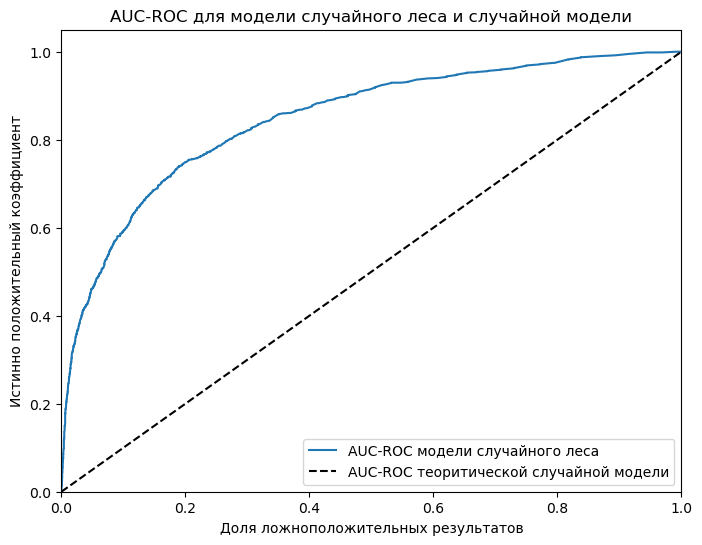

In [24]:
fpr, tpr, thresholds = roc_curve(target_test, predictions_proba[:, 1])

#Визуализация
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label='AUC-ROC модели случайного леса')
plt.plot([0, 1], [0, 1], 'k--', label='AUC-ROC теоритической случайной модели')  # Диагональная линия для сравнения - AUC ROC случайной модели в теории
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Доля ложноположительных результатов')
plt.ylabel('Истинно положительный коэффициент')
plt.title('AUC-ROC для модели случайного леса и случайной модели')
plt.legend(loc="lower right")
plt.show();

#### Вывод:
- AUC-ROC равная 0.84 говорит о высоком качестве модели. В данном случае значение указывает на то, что модель хорошо различает между классами и имеет высокую способность отличать положительные и отрицательные случаи.

## Общий вывод проекта:

## Project Conclusion:

- Было проведено исследование оценки наиболее оптимальной модели для задачи оценки потенциального ухода клиента из банка в ближайшее время.
- На выбор к оценке были три модели:
   - дерево решений  
   - случайный лес  
   - логистическая регрессия  
- Наиболее оптимальной в итоге оказалась модель:
   - случайного леса с приведением классов к балансу.  

---

- A study was conducted to determine the most optimal model for predicting potential customer churn in the near future.
- Three models were evaluated:
   - Decision Tree  
   - Random Forest  
   - Logistic Regression  
- The most optimal model turned out to be:
   - Random Forest with class balancing applied.